Question 1 (35 pt)

A sample of 30 respondents was interviewed using mall intercept interviewing. The respondents were asked to indicate their degree of agreement with the following statements using a seven-point scale (1 = strongly disagree, 7 = strongly agree).

•	V1 = It is important to buy a toothpaste that prevents cavities

•	V2 = I like a toothpaste that gives a shiny teeth

•	V3 = A toothpaste should strengthen your gums teeth

•	V4 = I prefer a toothpaste that freshens breath

•	V5 = Prevention of tooth decay is not an important benefit offered by a toothpaste

•	V6 = The most important consideration in buying a toothpaste is attractive teeth

By using the variables,

(1) How many factors is extracted from data for principal component analysis?

(2) What is the total percentage of variance explained by these principal components?

(3)Which variables are included in the same factors ? How can you name these factors?

You can find the data at

https://raw.githubusercontent.com/ogut77/DataScience/main/data/Toothpaste.csv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=9c776361fb7c259a501e4a8947775f2257062d2955275c069b6c71cefa5f00d0
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer
Shape: (30, 6)
    V1   V2   V3   V4   V5   V6
0  7.0  3.0  6.0  4.0  2.0  4.0
1  1.0  3.0  2.0  4.0  5.0  4.0
2  6.0  2.0  7.0  4.0  1.0  3.0
3  4.0  5.0  4.0  6.0  6.0  5.0
4  1.0  2.0  2.0  3.0  2.0  2.0
              V1         V2         V3         V4         V5         V6
count  30.000000  30.000000  30.000000  30.000000  30.000000  30.000000
mean    3.933333   3.900000   4.100000   4.100000   3.633333   4.166667
std     1.981524   1.373392   2.056948   1.37339

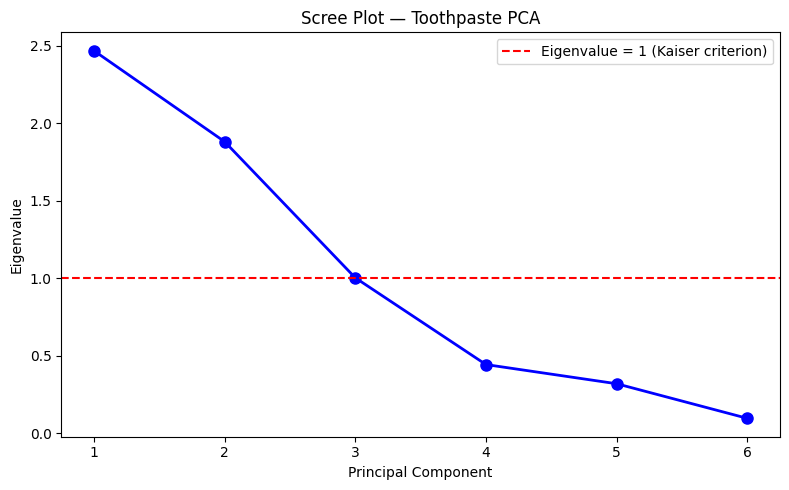


(3) Rotated Factor Loadings (Varimax):
    Factor1  Factor2  Factor3
V1   -0.009    0.874   -0.107
V2    0.729   -0.034    0.206
V3   -0.110    0.976   -0.176
V4    0.732   -0.104    0.206
V5    0.056   -0.106    0.443
V6    0.955    0.011   -0.291

Variable-to-Factor Assignment:
   Dominant_Factor
V1         Factor2
V2         Factor1
V3         Factor2
V4         Factor1
V5         Factor3
V6         Factor1

Factor naming guide:
- Variables loading on Factor 1 → likely 'Health/Protection' factor
- Variables loading on Factor 2 → likely 'Cosmetic/Appearance' factor
(Interpret based on your actual output)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [5]:
#Question1
# ============================================================
# Q1 (35 pt) — Principal Component Analysis: Toothpaste Data
# ============================================================
!pip install factor_analyzer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer

# Install if needed: pip install factor_analyzer

df = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/Toothpaste.csv')
print("Shape:", df.shape)
print(df.head())
print(df.describe())

# --- Step 1: Standardize the data ---
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# --- Step 2: Run PCA to find eigenvalues (Kaiser criterion: eigenvalue > 1) ---
pca = PCA()
pca.fit(df_scaled)

eigenvalues = pca.explained_variance_
print("\nEigenvalues:")
for i, ev in enumerate(eigenvalues):
    print(f"  PC{i+1}: {ev:.4f}")

# (1) Number of factors with eigenvalue > 1
n_factors = sum(eigenvalues > 1)
print(f"\n(1) Number of factors extracted (eigenvalue > 1): {n_factors}")

# (2) Total variance explained by selected components
explained_ratio = pca.explained_variance_ratio_
total_var = sum(explained_ratio[:n_factors]) * 100
print(f"(2) Total variance explained by {n_factors} factors: {total_var:.2f}%")

# Print variance table
print("\nVariance Explained Table:")
cumvar = 0
for i in range(len(eigenvalues)):
    cumvar += explained_ratio[i] * 100
    print(f"  PC{i+1}: Eigenvalue={eigenvalues[i]:.4f} | Variance={explained_ratio[i]*100:.2f}% | Cumulative={cumvar:.2f}%")

# --- Scree Plot ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1 (Kaiser criterion)')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot — Toothpaste PCA')
plt.legend()
plt.xticks(range(1, len(eigenvalues)+1))
plt.tight_layout()
plt.show()

# --- Step 3: Factor Analysis with Varimax Rotation ---
# (3) Which variables are in the same factors? Name the factors.
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(df)

loadings = pd.DataFrame(
    fa.loadings_,
    index=df.columns,
    columns=[f'Factor{i+1}' for i in range(n_factors)]
)
print("\n(3) Rotated Factor Loadings (Varimax):")
print(loadings.round(3))

# Assign each variable to the factor with the highest absolute loading
loadings['Dominant_Factor'] = loadings.abs().idxmax(axis=1)
print("\nVariable-to-Factor Assignment:")
print(loadings[['Dominant_Factor']])

# Factor interpretation guide
# V1 = prevents cavities (health/protection)
# V2 = shiny teeth (cosmetic)
# V3 = strengthen gums (health/protection)
# V4 = freshens breath (cosmetic/freshness)
# V5 = tooth decay NOT important (reverse health)
# V6 = attractive teeth (cosmetic)
print("""
Factor naming guide:
- Variables loading on Factor 1 → likely 'Health/Protection' factor
- Variables loading on Factor 2 → likely 'Cosmetic/Appearance' factor
(Interpret based on your actual output)
""")


In [2]:
#Q2  is below
# Data description is provided below
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/Leads.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [6]:
 #There are missing values in the Lead data .
# Replace missing variables with the mean  if variable is numeric or mode if variable is categorical.
for col in df.columns:
    if ((df[col].dtype == 'float64') or (df[col].dtype == 'float64')) :
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


In [7]:
#Check that there are no missing data
df.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reload data fresh ---
df = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/Leads.csv')

# --- Fill missing values ---
for col in df.columns:
    if (df[col].dtype == 'float64') or (df[col].dtype == 'int64'):
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# --- Prepare X and y ---
df2 = df.drop(columns=['Prospect ID', 'Lead Number'])
y = df2['Converted']
X = df2.drop(columns=['Converted'])

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Done — ready for AutoGluon!")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split



df = df.drop(columns=['Prospect ID', 'Lead Number'], errors='ignore')
y = df['Converted']
X = df.drop(columns=['Converted'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

X_train shape: (6468, 34)
X_test shape: (2772, 34)
Done — ready for AutoGluon!


In [13]:
def eval(yact,ypred):
 from sklearn import metrics
 print("Accuracy:",metrics.accuracy_score(yact, ypred))
 print("Precision:",metrics.precision_score(yact, ypred))
 print("Recall:",metrics.recall_score(yact, ypred))

 cnf_matrix = metrics.confusion_matrix(yact, ypred)
 import numpy as np
 import matplotlib.pyplot as plt
 import seaborn as sns
 %matplotlib inline
 class_names=[0,1] # name  of classes
 fig, ax = plt.subplots()
 tick_marks = np.arange(len(class_names))
 plt.xticks(tick_marks, class_names)
 plt.yticks(tick_marks, class_names)
 # create heatmap
 sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
 ax.xaxis.set_label_position("top")
 plt.tight_layout()
 plt.title('Confusion matrix', y=1.1)
 plt.ylabel('Actual label')
 plt.xlabel('Predicted label')


No path specified. Models will be saved in: "AutogluonModels/ag-20260501_210844"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.48 GB / 12.67 GB (82.7%)
Disk Space Avail:   86.61 GB / 107.72 GB (80.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stac

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

Beginning AutoGluon training ... Time limit = 30s
AutoGluon will save models to "/content/AutogluonModels/ag-20260501_210844/ds_sub_fit/sub_fit_ho"
Train Data Rows:    5749
Train Data Columns: 34
Label Column:       Converted
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    10741.29 MB
	Train Data (Original)  Memory Usage: 9.16 MB (0.1% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 8 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting C

[1000]	valid_set's binary_error: 0.0457921


	0.9389	 = Validation score   (accuracy)
	12.63s	 = Training   runtime
	0.43s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 44.97s of the 74.21s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)
	0.9371	 = Validation score   (accuracy)
	11.05s	 = Training   runtime
	0.2s	 = Validation runtime
Fitting model: RandomForestGini_BAG_L1 ... Training model for up to 33.51s of the 62.75s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=2, gpus=0, mem=0.0/10.5 GB
	0.9167	 = Validation score   (accuracy)
	2.45s	 = Training   runtime
	0.28s	 = Validation runtime
Fitting model: RandomForestEntr_BAG_L1 ... Training model for up to 30.72s of the 59.96s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=2, gpus=0, mem=0.0/10.5 GB
	0.9162	 = Validation score   (accuracy)
	2.95s	 = Training   runtime
	0.59

Accuracy : 0.9365079365079365
Precision: 0.9206349206349206
Recall   : 0.9155060352831941


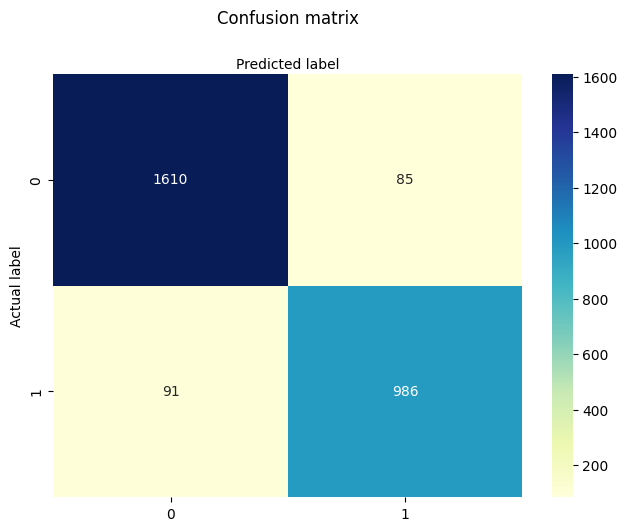


AutoGluon Model Leaderboard:
                      model  score_test  score_val eval_metric  \
0         LightGBMXT_BAG_L2    0.940837   0.938466    accuracy   
1           LightGBM_BAG_L1    0.939394   0.937075    accuracy   
2   RandomForestEntr_BAG_L2    0.939394   0.939394    accuracy   
3         LightGBMXT_BAG_L1    0.939033   0.938930    accuracy   
4       WeightedEnsemble_L2    0.939033   0.938930    accuracy   
5   RandomForestGini_BAG_L2    0.937590   0.938776    accuracy   
6           LightGBM_BAG_L2    0.936508   0.940940    accuracy   
7       WeightedEnsemble_L3    0.936508   0.940940    accuracy   
8    NeuralNetFastAI_BAG_L1    0.934704   0.915739    accuracy   
9   RandomForestEntr_BAG_L1    0.926407   0.916203    accuracy   
10  RandomForestGini_BAG_L1    0.924242   0.916667    accuracy   
11    ExtraTreesEntr_BAG_L1    0.918831   0.908472    accuracy   
12    ExtraTreesGini_BAG_L1    0.916306   0.906926    accuracy   

    pred_time_test  pred_time_val   fit_time 

In [18]:
#Q2(30 pt)-Using Autogluon  AutoML tools,make prediction on test data and evaluate performance of prediction using eval function defined above.

# ============================================================
# Q2 (30 pt) — AutoGluon AutoML on Leads Dataset
# ============================================================

# Install if needed:
!pip install autogluon.tabular

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.tabular import TabularPredictor

# --- Load data ---
df = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/Leads.csv')
print(df.info())
print(df.head())

# --- Replace missing values (mean for numeric, mode for categorical) ---
for col in df.columns:
    if (df[col].dtype == 'float64') or (df[col].dtype == 'int64'):
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify no missing values
print("\nMissing values after imputation:")
print(df.isnull().sum())

# --- Prepare features and target ---
df = df.drop(columns=['Prospect ID', 'Lead Number'])
y = df['Converted']
X = df.drop(columns=['Converted'])

# --- Train/test split (70/30) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# --- Build full training DataFrame for AutoGluon ---
train_data = X_train.copy()
train_data['Converted'] = y_train.values

# --- Train AutoGluon predictor ---
predictor = TabularPredictor(
    label='Converted',
    eval_metric='accuracy'
).fit(
    train_data,
    time_limit=120,          # seconds — increase for better accuracy
    presets='best_quality'  # or 'medium_quality' for speed
)

# --- Predict on test set ---
y_pred = predictor.predict(X_test)

# --- Eval function (as defined in the assignment) ---
def eval(yact, ypred):
    print("Accuracy :", metrics.accuracy_score(yact, ypred))
    print("Precision:", metrics.precision_score(yact, ypred))
    print("Recall   :", metrics.recall_score(yact, ypred))

    cnf_matrix = metrics.confusion_matrix(yact, ypred)
    class_names = [0, 1]
    fig, ax = plt.subplots()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
    ax.xaxis.set_label_position("top")
    plt.tight_layout()
    plt.title('Confusion matrix', y=1.1)
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

# --- Evaluate ---
eval(y_test, y_pred)

# --- Show AutoGluon leaderboard ---
print("\nAutoGluon Model Leaderboard:")

# Combine X_test and y_test into one DataFrame for leaderboard
test_data = X_test.copy()
test_data['Converted'] = y_test.values

print(predictor.leaderboard(test_data, silent=True))


Shape: (178, 13)
      f1    f2    f3    f4   f5    f6    f7    f8    f9   f10   f11   f12  \
0  14.23  1.71  2.43  15.6  127  2.80  3.06  0.28  2.29  5.64  1.04  3.92   
1  13.20  1.78  2.14  11.2  100  2.65  2.76  0.26  1.28  4.38  1.05  3.40   
2  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81  5.68  1.03  3.17   
3  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18  7.80  0.86  3.45   
4  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82  4.32  1.04  2.93   

    f13  
0  1065  
1  1050  
2  1185  
3  1480  
4   735  


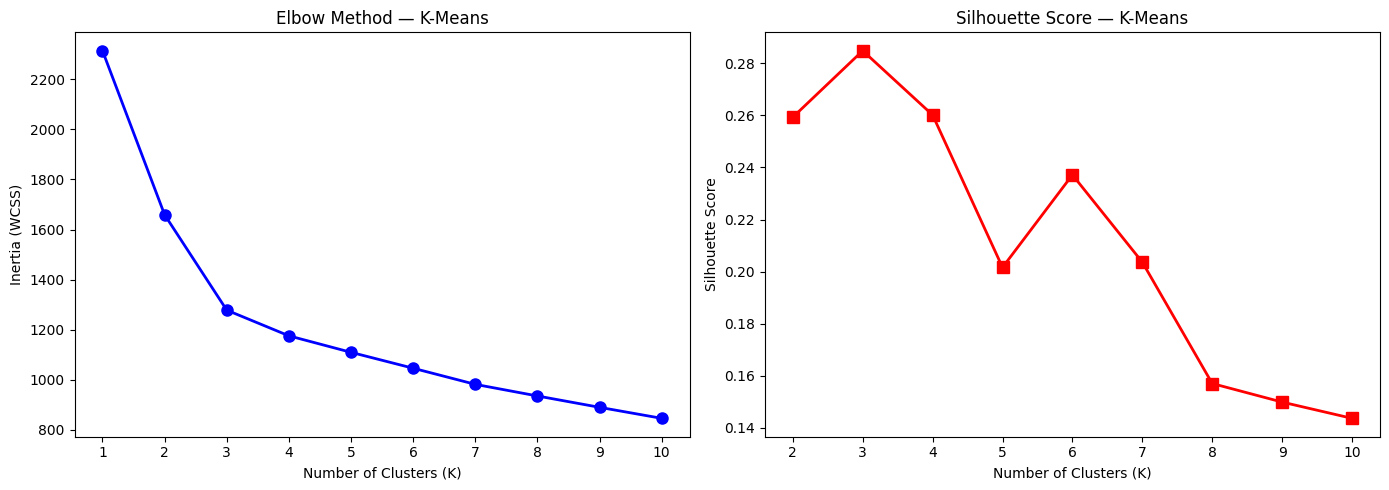


Elbow Method Table:
  K=1: WCSS=2314.00
  K=2: WCSS=1658.76
  K=3: WCSS=1277.93
  K=4: WCSS=1175.43
  K=5: WCSS=1109.51
  K=6: WCSS=1046.00
  K=7: WCSS=981.60
  K=8: WCSS=935.20
  K=9: WCSS=889.89
  K=10: WCSS=845.90

Optimal K (silhouette): 3
(Visually confirm the elbow in the WCSS plot above)

K-Means cluster sizes (K=3):
KMeans_Cluster
0    65
1    51
2    62
Name: count, dtype: int64


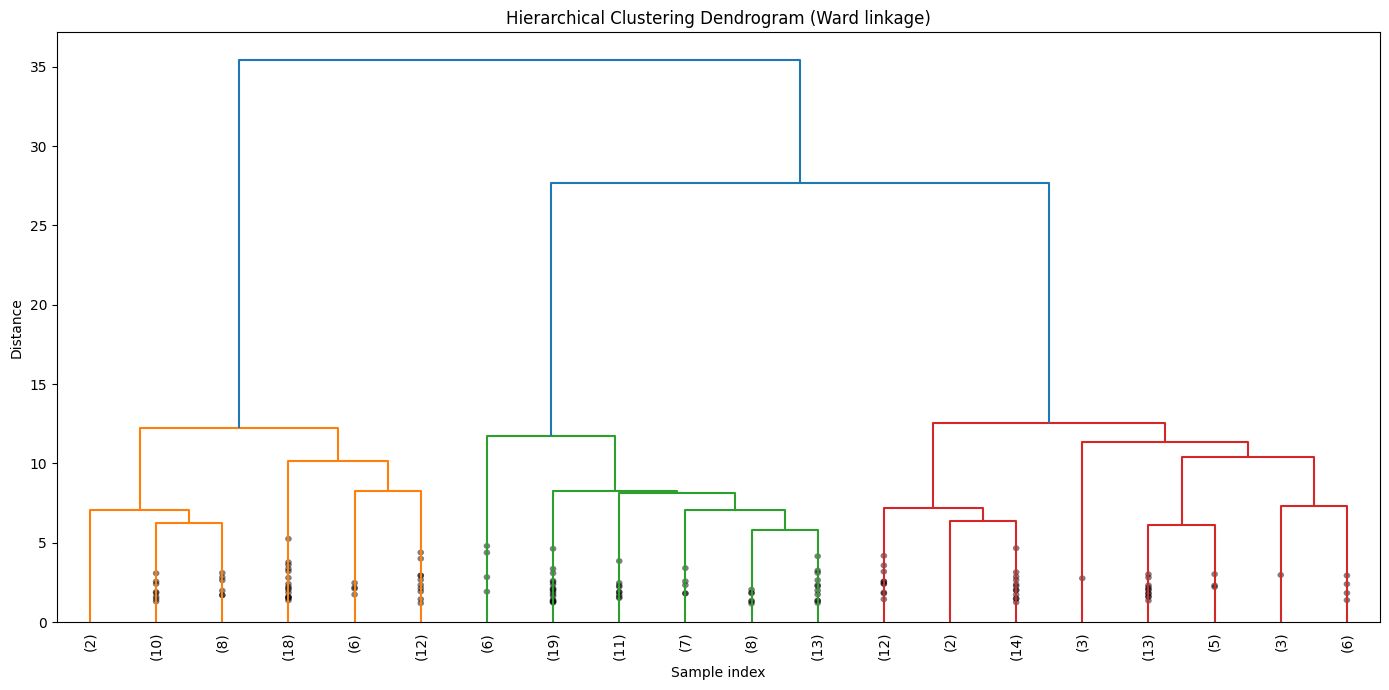


Hierarchical cluster sizes (K=3):
Hier_Cluster
1    56
2    64
3    58
Name: count, dtype: int64

Final answer: The optimal number of clusters is 3
      f1    f2    f3    f4   f5    f6    f7    f8    f9   f10   f11   f12  \
0  14.23  1.71  2.43  15.6  127  2.80  3.06  0.28  2.29  5.64  1.04  3.92   
1  13.20  1.78  2.14  11.2  100  2.65  2.76  0.26  1.28  4.38  1.05  3.40   
2  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81  5.68  1.03  3.17   
3  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18  7.80  0.86  3.45   
4  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82  4.32  1.04  2.93   

    f13  KMeans_Cluster  Hier_Cluster  
0  1065               2             2  
1  1050               2             2  
2  1185               2             2  
3  1480               2             2  
4   735               2             2  


In [20]:
#Q3(35 pt)-Using data below, find how many clusters are there based on elbow method for k-means
#and hierarchical clustering
import pandas as pd
import numpy as np
cl = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/refs/heads/main/cluster.csv')
cl
# ============================================================
# Q3 (35 pt) — K-Means Elbow Method + Hierarchical Clustering
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# --- Load data ---
cl = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/refs/heads/main/cluster.csv')
print("Shape:", cl.shape)
print(cl.head())

# --- Standardize ---
scaler = StandardScaler()
cl_scaled = scaler.fit_transform(cl)

# ===================================================
# Part A: K-Means — Elbow Method
# ===================================================
inertias = []
silhouettes = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cl_scaled)
    inertias.append(km.inertia_)
    if k > 1:
        score = silhouette_score(cl_scaled, km.labels_)
        silhouettes.append(score)
    else:
        silhouettes.append(None)

# --- Plot Elbow Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method — K-Means')
axes[0].set_xticks(list(K_range))

sil_vals = [s for s in silhouettes if s is not None]
axes[1].plot(range(2, 11), sil_vals, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — K-Means')
axes[1].set_xticks(range(2, 11))

plt.tight_layout()
plt.show()

# Print inertia table
print("\nElbow Method Table:")
for k, ine in zip(K_range, inertias):
    print(f"  K={k}: WCSS={ine:.2f}")

optimal_k_sil = sil_vals.index(max(sil_vals)) + 2
print(f"\nOptimal K (silhouette): {optimal_k_sil}")
print(f"(Visually confirm the elbow in the WCSS plot above)")

# --- Final K-Means with optimal K ---
km_final = KMeans(n_clusters=optimal_k_sil, random_state=42, n_init=10)
cl['KMeans_Cluster'] = km_final.fit_predict(cl_scaled)
print(f"\nK-Means cluster sizes (K={optimal_k_sil}):")
print(cl['KMeans_Cluster'].value_counts().sort_index())

# ===================================================
# Part B: Hierarchical Clustering — Dendrogram
# ===================================================
linked = linkage(cl_scaled, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Cut dendrogram to get cluster labels
cl['Hier_Cluster'] = fcluster(linked, t=optimal_k_sil, criterion='maxclust')
print(f"\nHierarchical cluster sizes (K={optimal_k_sil}):")
print(cl['Hier_Cluster'].value_counts().sort_index())

print("\nFinal answer: The optimal number of clusters is", optimal_k_sil)
print(cl.head())
